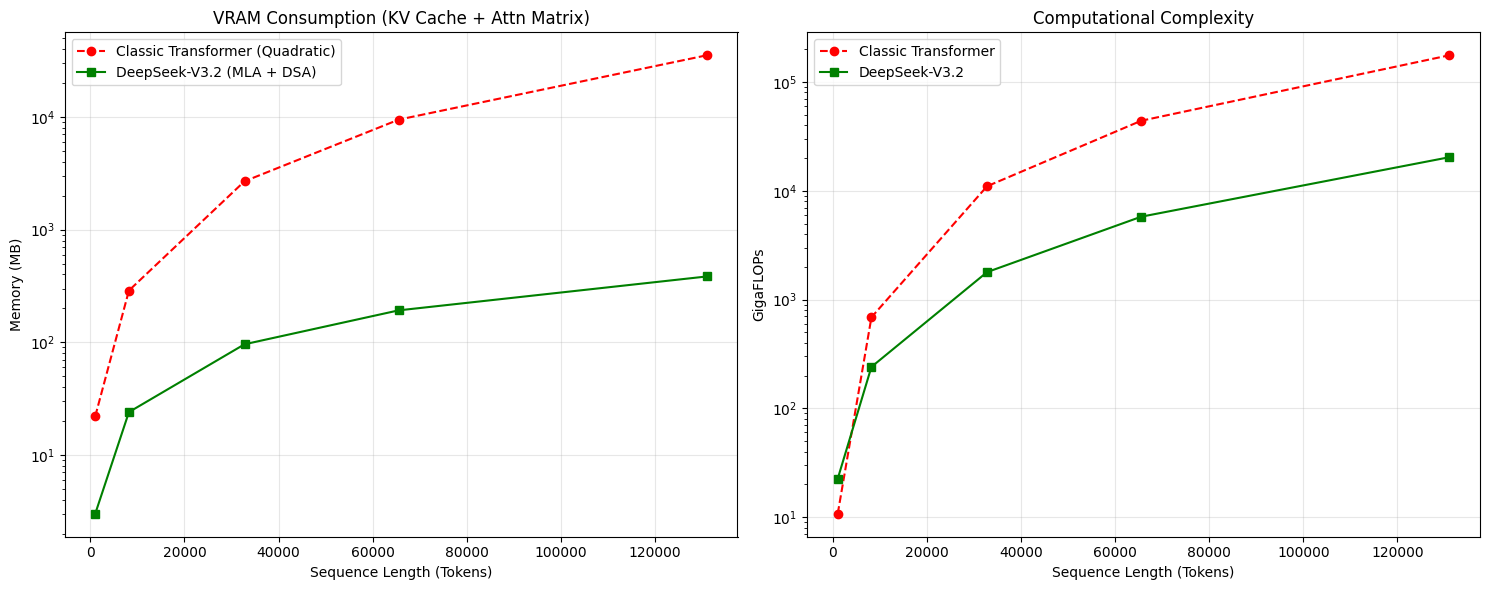

In [11]:
import numpy as np
import matplotlib.pyplot as plt

def calculate_realistic_metrics(seq_length, is_dsa=False):
    """
    Simulates DeepSeek-V3.2 Architecture Specs:
    - Hidden Dim (d): 5120
    - MLA Latent Dim (d_c): 512
    - Top-k: 2048 (Actual DeepSeek-V3.2 setting)
    - Indexer Heads: 16
    - Precision: FP8 (1 byte) for Indexer, FP16 (2 bytes) for KV Cache
    """
    # Model Architecture Constants
    d = 5120         # Hidden dimension
    d_c = 512        # Latent KV compression dimension (MLA)
    k = 2048         # DeepSeek-V3.2 selection window
    n_heads = 128    # Number of attention heads
    
    # 1. COMPUTE (GigaFLOPs)
    if not is_dsa:
        # Classic Attention: N^2 * d
        # Standard QK^T + Softmax(QK^T)V
        flops = (2 * seq_length**2 * d) / 1e9
    else:
        # DeepSeek DSA:
        # Stage 1: Lightning Indexer (N^2 but very "thin" heads)
        d_indexer = 32
        indexer_heads = 16
        indexer_flops = (2 * seq_length**2 * d_indexer * indexer_heads) / 1e9
        
        # Stage 2: Sparse Attention (N * k * d)
        sparse_attn_flops = (2 * seq_length * k * d) / 1e9
        flops = indexer_flops + sparse_attn_flops

    # 2. VRAM (Megabytes)
    # Only measuring the attention-related memory (KV Cache + Score Matrix)
    if not is_dsa:
        # Classic: N^2 matrix (FP16) + N * d KV Cache
        matrix_mem = (seq_length**2 * 2) / (1024**2)
        kv_cache = (seq_length * d * 2 * 2) / (1024**2) # K and V
        total_vram = matrix_mem + kv_cache
    else:
        # DeepSeek DSA: 
        # N * d_c (MLA Compressed KV) + N * k (Sparse Matrix)
        # DeepSeek uses FP8 for Indexer scores
        sparse_matrix_mem = (seq_length * k * 1) / (1024**2)
        mla_kv_cache = (seq_length * d_c * 2) / (1024**2) 
        total_vram = sparse_matrix_mem + mla_kv_cache
        
    return flops, total_vram

# Test across Long Context (up to 128k)
seq_range = [1024, 8192, 32768, 65536, 131072]
classic_f, classic_v = [], []
dsa_f, dsa_v = [], []

for n in seq_range:
    f, v = calculate_realistic_metrics(n, is_dsa=False)
    classic_f.append(f); classic_v.append(v)
    
    f, v = calculate_realistic_metrics(n, is_dsa=True)
    dsa_f.append(f); dsa_v.append(v)

# --- PLOTTING ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# VRAM Plot
ax1.plot(seq_range, classic_v, 'r--o', label='Classic Transformer (Quadratic)')
ax1.plot(seq_range, dsa_v, 'g-s', label='DeepSeek-V3.2 (MLA + DSA)')
ax1.set_title('VRAM Consumption (KV Cache + Attn Matrix)')
ax1.set_ylabel('Memory (MB)')
ax1.set_xlabel('Sequence Length (Tokens)')
ax1.set_yscale('log')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Compute Plot
ax2.plot(seq_range, classic_f, 'r--o', label='Classic Transformer')
ax2.plot(seq_range, dsa_f, 'g-s', label='DeepSeek-V3.2')
ax2.set_title('Computational Complexity')
ax2.set_ylabel('GigaFLOPs')
ax2.set_xlabel('Sequence Length (Tokens)')
ax2.set_yscale('log')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()